# 고객 문의 자동 배정 — 토큰화 · 임베딩 · 의미공간

## 이번 실습에서 만드는 것
고객센터에는 매일 수백 건의 문의가 들어옵니다. 지금은 사람이 문의를 읽고 담당팀을 정합니다.
이 실습에서는 **문의 문장의 의미를 숫자로 바꾸고(임베딩), 가장 비슷한 FAQ를 찾아 담당팀을 자동으로 정하는** 프로그램을 만듭니다.

| 절 | 개념 | 결과물 |
|---|---|---|
| 3 | 토큰과 토큰화 | 문장이 토큰으로 나뉘는 모습 |
| 4 | 임베딩 | 문장 1개 → 숫자 1,024개 |
| 5 | 의미공간과 유사도 | 문장 사이의 거리 |
| 6 | 자동 배정 | 문의 20건의 담당팀 배정표 |

> API 키가 필요 없습니다. 임베딩 모델을 내 컴퓨터(또는 Colab)에서 직접 실행합니다.
> 실습 배경: 온라인 가전 쇼핑몰 **하이마켓**의 고객센터

## 1. 준비 — 패키지 설치

| 패키지 | 역할 |
|---|---|
| `tiktoken` | 토크나이저. 문장을 토큰으로 나누고 개수를 셉니다 |
| `sentence-transformers` | 임베딩 모델. 문장을 숫자 벡터로 바꿉니다 |
| `scikit-learn` | 코사인 유사도 계산, 차원 축소(PCA) |
| `pandas` | 표 |
| `matplotlib` | 그래프 |

In [1]:
# Colab·VS Code 공통. -q는 설치 과정의 출력을 줄이는 옵션입니다.
!pip install -q tiktoken sentence-transformers scikit-learn pandas matplotlib

In [3]:
import tiktoken                                             # 토크나이저
import pandas as pd                                         # 표
import numpy as np                                          # 수치 계산
from sentence_transformers import SentenceTransformer      # 임베딩 모델
from sklearn.metrics.pairwise import cosine_similarity     # 코사인 유사도
from sklearn.decomposition import PCA                       # 차원 축소
import matplotlib.pyplot as plt                             # 그래프

pd.set_option("display.max_colwidth", 60)                   # 표에서 긴 문장이 잘리지 않도록 설정
print("준비 완료")

Matplotlib is building the font cache; this may take a moment.


준비 완료


## 2. 실습 데이터 — FAQ 12건과 고객 문의 20건

데이터는 두 종류입니다.

| 데이터 | 내용 | 역할 |
|---|---|---|
| FAQ 12건 | 질문 · 답변 · 담당팀 | 비교 기준. 담당팀이 이미 정해져 있습니다 |
| 고객 문의 20건 | 오늘 들어온 문의 문장 | 담당팀을 정해야 할 대상 |

**포인트** — 문의와 가장 비슷한 FAQ를 찾으면, 그 FAQ의 담당팀이 곧 문의의 담당팀입니다.

In [4]:
# 비교 기준: FAQ 12건. 한 줄이 [질문, 답변, 담당팀]입니다.
faq = pd.DataFrame([
    ["주문한 상품은 언제 배송되나요?",        "결제 완료 후 1~2일 내 출고되며, 출고 후 송장번호가 문자로 발송됩니다.", "배송팀"],
    ["배송지 주소나 연락처를 변경하고 싶어요.", "출고 전이면 마이페이지에서 배송지·수령인 연락처를 직접 바꿀 수 있습니다.", "배송팀"],
    ["주문을 취소하고 환불받고 싶어요.",       "출고 전 주문은 즉시 취소되며, 환불은 결제 수단으로 되돌려 드립니다.", "환불팀"],
    ["환불은 며칠 뒤에 입금되나요?",           "카드 결제는 취소 후 3~5영업일, 계좌 환불은 2영업일 안에 입금됩니다.", "환불팀"],
    ["카드 결제가 계속 실패해요.",             "한도 초과·해외결제 차단·앱카드 미인증이 주된 원인이며, 다른 카드로 재시도해 주세요.", "결제팀"],
    ["무통장 입금은 언제 확인되나요?",         "입금 후 10분 안에 자동 확인되며, 입금자명이 다르면 확인이 지연될 수 있습니다.", "결제팀"],
    ["현금영수증이나 세금계산서 발급이 가능한가요?", "주문 상세에서 소득공제용 현금영수증 또는 사업자 세금계산서를 신청할 수 있습니다.", "결제팀"],
    ["비밀번호를 잊어버렸어요.",               "로그인 화면의 '비밀번호 찾기'에서 휴대폰 인증 후 새 비밀번호를 설정합니다.", "회원팀"],
    ["휴대폰 번호가 바뀌어서 본인인증이 안 돼요.", "고객센터에 신분증 사본을 보내 주시면 등록된 번호를 새 번호로 바꿔 드립니다.", "회원팀"],
    ["회원 탈퇴는 어떻게 하나요?",             "마이페이지 > 회원정보 > 회원 탈퇴에서 계정을 삭제할 수 있으며, 진행 중인 주문이 없어야 합니다.", "회원팀"],
    ["상품이 파손된 채로 도착했어요. 교환이나 반품이 되나요?", "수령 후 7일 안에 파손 사진을 보내 주시면 무상 교환 또는 반품 처리해 드립니다.", "CS팀"],
    ["제품 고장 시 A/S와 보증기간은 어떻게 되나요?", "구매일로부터 1년간 무상 A/S가 제공되며, 제조사 서비스센터 방문 또는 택배 접수가 가능합니다.", "CS팀"],
], columns=["faq_질문", "faq_답변", "담당팀"])

# 배정 대상: 오늘 들어온 고객 문의 20건. 담당팀은 이 실습에서 정합니다.
inquiries = [
    "어제 주문했는데 아직 출발도 안 했네요. 언제쯤 받을 수 있을까요?",
    "주소를 잘못 입력했어요. 아파트 동호수 바꿀 수 있나요?",
    "마음이 바뀌어서 주문 취소하려고요. 돈은 언제 돌려주나요?",
    "환불 신청한 지 일주일이 지났는데 아직 입금이 안 됐어요.",
    "결제 버튼을 누르면 오류가 나면서 승인이 안 돼요.",
    "회사 경비 처리해야 해서 세금계산서 발행 부탁드립니다.",
    "로그인이 안 돼요. 비밀번호 찾기는 어디서 하나요?",
    "더 이상 이용 안 할 건데 계정 삭제하고 싶습니다.",
    "택배 상자를 열었더니 액정이 깨져 있어요.",
    "산 지 두 달 된 청소기가 갑자기 안 켜져요. 수리 가능한가요?",
    "송장번호가 조회가 안 되는데 배송 중인 게 맞나요?",
    "받는 사람 연락처를 바꾸고 싶어요.",
    "취소했는데 환불 금액이 결제 금액보다 적게 들어왔어요.",
    "무통장 입금했는데 주문이 미결제로 떠요.",
    "현금영수증 소득공제용으로 받을 수 있나요?",
    "휴대폰 번호가 바뀌어서 인증이 안 돼요.",
    "냉장고 문이 찌그러져서 왔어요. 교환해 주세요.",
    "제품 보증기간이 얼마나 되나요?",
    "오늘 아침에 주문했는데 새벽배송 되나요?",
    "채용 공고는 어디에서 볼 수 있나요?",
]
print(f"FAQ {len(faq)}건, 고객 문의 {len(inquiries)}건")
faq

FAQ 12건, 고객 문의 20건


,faq_질문,faq_답변,담당팀
0,주문한 상품은 언제 배송되나요?,"결제 완료 후 1~2일 내 출고되며, 출고 후 송장번호가 문자로 발송됩니다.",배송팀
1,배송지 주소나 연락처를 변경하고 싶어요.,출고 전이면 마이페이지에서 배송지·수령인 연락처를 직접 바꿀 수 있습니다.,배송팀
2,주문을 취소하고 환불받고 싶어요.,"출고 전 주문은 즉시 취소되며, 환불은 결제 수단으로 되돌려 드립니다.",환불팀
3,환불은 며칠 뒤에 입금되나요?,"카드 결제는 취소 후 3~5영업일, 계좌 환불은 2영업일 안에 입금됩니다.",환불팀
4,카드 결제가 계속 실패해요.,"한도 초과·해외결제 차단·앱카드 미인증이 주된 원인이며, 다른 카드로 재시도해 주세요.",결제팀
5,무통장 입금은 언제 확인되나요?,"입금 후 10분 안에 자동 확인되며, 입금자명이 다르면 확인이 지연될 수 있습니다.",결제팀
6,현금영수증이나 세금계산서 발급이 가능한가요?,주문 상세에서 소득공제용 현금영수증 또는 사업자 세금계산서를 신청할 수 있습니다.,결제팀
7,비밀번호를 잊어버렸어요.,로그인 화면의 '비밀번호 찾기'에서 휴대폰 인증 후 새 비밀번호를 설정합니다.,회원팀
8,휴대폰 번호가 바뀌어서 본인인증이 안 돼요.,고객센터에 신분증 사본을 보내 주시면 등록된 번호를 새 번호로 바꿔 드립니다.,회원팀
9,회원 탈퇴는 어떻게 하나요?,"마이페이지 > 회원정보 > 회원 탈퇴에서 계정을 삭제할 수 있으며, 진행 중인 주문이 없어야 합니다.",회원팀


## 3. 토큰과 토큰화 — 모델은 문장을 토큰 단위로 읽는다

LLM은 문장을 글자 그대로 읽지 않습니다. 먼저 문장을 **토큰(Token)** 이라는 작은 단위로 나누고,
각 토큰을 **숫자(토큰 ID)** 로 바꿉니다. 이 과정이 **토큰화(Tokenization)** 입니다.

**용어** — 토큰은 단어 하나일 수도, 단어의 일부일 수도, 문장부호일 수도 있습니다.
같은 문장이라도 토크나이저(나누는 규칙)에 따라 토큰 수가 달라집니다.

**포인트** — 토큰 수는 곧 **비용과 한도**입니다. API 요금과 컨텍스트 윈도우는 모두 토큰 단위로 계산됩니다.

In [ ]:
# GPT-4o 계열 모델의 토크나이저(o200k_base)를 불러옵니다.
enc = tiktoken.get_encoding("o200k_base")

sentence = "갤럭시가 출시되었습니다."
ids = enc.encode(sentence)                                  # 문장 → 토큰 ID 목록

print("문장   :", sentence)
print("토큰 ID:", ids)
print("토큰 수:", len(ids))
print("토큰   :", [enc.decode([i]) for i in ids])          # 토큰 ID → 원래 글자

# 문장이 Token, Sequence 형태로 저장됨

문장   : 갤럭시가 출시되었습니다.
토큰 ID: [2571, 97, 140597, 5637, 4081, 142237, 136069, 13]
토큰 수: 8
토큰   : ['�', '�', '럭', '시', '가', ' 출시', '되었습니다', '.']


**포인트** — 첫 글자 "갤"이 `�` 두 개로 표시되는 것은 오류가 아닙니다.
자주 쓰이지 않는 글자는 **글자 하나보다 작은 단위(바이트)** 로 나뉘기 때문입니다.
교안의 "갤 / ##럭 / ##시" 예시가 바로 이 현상입니다.

같은 뜻이라도 언어에 따라 토큰 수가 다릅니다. 한국어가 영어보다 토큰이 많으므로 비용도 더 듭니다.

In [6]:
# 같은 뜻의 한국어·영어 문장을 토큰 수로 비교합니다.
pairs = [
    ("주문한 상품은 언제 배송되나요?", "When will my order be delivered?"),
    ("환불은 며칠 뒤에 입금되나요?",   "How many days until the refund is deposited?"),
]
for ko, en in pairs:
    print(f"한국어 {len(enc.encode(ko)):2d}토큰 | 영어 {len(enc.encode(en)):2d}토큰 | {ko}")

한국어 10토큰 | 영어  7토큰 | 주문한 상품은 언제 배송되나요?
한국어 13토큰 | 영어  9토큰 | 환불은 며칠 뒤에 입금되나요?


## 4. 임베딩 — 문장을 의미가 담긴 숫자로 바꾼다

토큰 ID는 번호일 뿐, 의미를 담고 있지 않습니다.
**임베딩(Embedding)** 은 문장을 **의미를 담은 숫자 목록(벡터)** 으로 바꾸는 기술입니다.
뜻이 비슷한 문장은 비슷한 숫자 목록이 됩니다.

**용어** — 벡터는 숫자를 순서대로 나열한 것입니다. 이 실습의 모델은 문장 하나를 숫자 1,024개로 표현합니다.

**포인트** — 임베딩은 검색·추천·분류의 공통 기반 기술입니다. **"의미를 숫자로 비교하는 도구"** 로 기억하세요.

In [ ]:
# 한국어 성능이 검증된 다국어 임베딩 모델을 불러옵니다. (첫 실행 시 약 2.2GB 다운로드, CPU로 실행)
model = SentenceTransformer("BAAI/bge-m3", device="cpu")

vec = model.encode("주문한 상품은 언제 배송되나요?")           # 문장 1개 → 벡터 1개
print("벡터 길이:", len(vec))
print("앞 5개 값:", np.round(vec[:5], 3))

# 문장을 넣었을 때, 숫자로 이루어진 vector로 만든다.
# 임베딩 모델을 사용함

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 52951.89it/s]


벡터 길이: 1024
앞 5개 값: [-0.038  0.005 -0.025 -0.009 -0.005]


## 5. 의미공간 — 뜻이 비슷한 문장은 가까이 있다

임베딩된 문장은 **의미공간(Semantic Space)** 안의 점 하나가 됩니다.
두 점이 얼마나 가까운지는 **코사인 유사도**로 측정합니다. 값이 1에 가까울수록 뜻이 같고, 0에 가까울수록 관련이 없습니다.

**용어** — 코사인 유사도는 두 벡터가 **같은 방향을 향하는 정도**입니다. 벡터의 길이가 아니라 방향을 비교합니다.

In [ ]:
# 문장 3개를 임베딩하고 서로의 유사도를 계산합니다.
samples = [
    "주문한 상품은 언제 배송되나요?",       # 배송 문의
    "택배가 언제 도착하는지 알고 싶어요.",    # 배송 문의 (다른 표현)
    "비밀번호를 잊어버렸어요.",             # 다른 주제
]
vecs = model.encode(samples)
sim = cosine_similarity(vecs)                               # 3×3 유사도 행렬

pd.DataFrame(sim, index=samples, columns=["배송 문의", "배송(다른 표현)", "비밀번호"]).round(2)

# 3문장을 임베딩해서 vector로 만들고 유사도 계산
# 의미가 얼마나 가까운 지 비교 가능함

,배송 문의,배송(다른 표현),비밀번호
주문한 상품은 언제 배송되나요?,1.00,0.81,0.42
택배가 언제 도착하는지 알고 싶어요.,0.81,1.00,0.50
비밀번호를 잊어버렸어요.,0.42,0.50,1.00


**포인트** — "배송되나요"와 "도착하는지"는 겹치는 단어가 없는데도 유사도가 높습니다.
글자가 아니라 **의미**를 비교하기 때문입니다. 이것이 키워드 검색과 임베딩 검색의 차이입니다.

### 의미공간을 그림으로 보기

1,024차원은 그릴 수 없으므로 **PCA**로 2차원으로 줄여서 그립니다. 점의 위치는 대략적인 배치입니다.

**용어** — PCA(주성분 분석)는 정보 손실을 최소화하면서 차원을 줄이는 방법입니다. 지구본을 평면 지도로 옮기는 것과 같습니다.

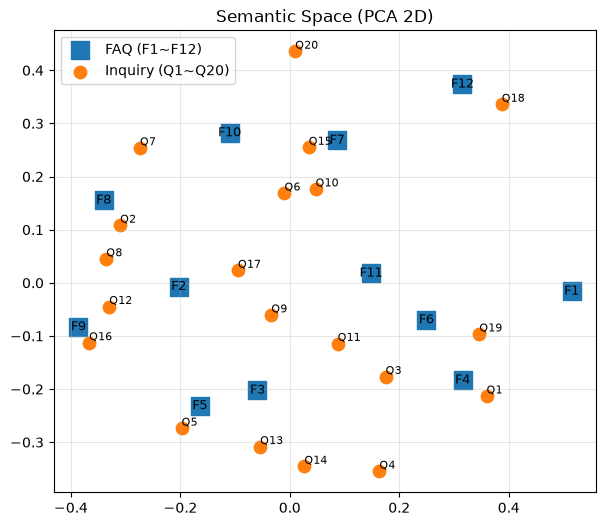

,번호,FAQ,담당팀
0,F1,주문한 상품은 언제 배송되나요?,배송팀
1,F2,배송지 주소나 연락처를 변경하고 싶어요.,배송팀
2,F3,주문을 취소하고 환불받고 싶어요.,환불팀
3,F4,환불은 며칠 뒤에 입금되나요?,환불팀
4,F5,카드 결제가 계속 실패해요.,결제팀
5,F6,무통장 입금은 언제 확인되나요?,결제팀
6,F7,현금영수증이나 세금계산서 발급이 가능한가요?,결제팀
7,F8,비밀번호를 잊어버렸어요.,회원팀
8,F9,휴대폰 번호가 바뀌어서 본인인증이 안 돼요.,회원팀
9,F10,회원 탈퇴는 어떻게 하나요?,회원팀


In [11]:
# FAQ 12건과 문의 20건을 임베딩하고, PCA로 2차원으로 줄여 그립니다.
faq_docs = faq["faq_질문"].tolist()                        # 비교 기준은 FAQ 질문 문장
faq_vecs = model.encode(faq_docs)
inq_vecs = model.encode(inquiries)

points = PCA(n_components=2).fit_transform(np.vstack([faq_vecs, inq_vecs]))

plt.figure(figsize=(7, 6))
plt.scatter(points[:12, 0], points[:12, 1], s=180, marker="s", label="FAQ (F1~F12)")
plt.scatter(points[12:, 0], points[12:, 1], s=80,  marker="o", label="Inquiry (Q1~Q20)")
for i in range(12):  plt.annotate(f"F{i+1}",    points[i],    fontsize=9, ha="center", va="center")
for i in range(20):  plt.annotate(f"Q{i+1}",    points[12+i], fontsize=8, ha="left",   va="bottom")
plt.title("Semantic Space (PCA 2D)"); plt.legend(); plt.grid(alpha=.3); plt.show()

# 그림의 번호(F1~F12)가 어떤 FAQ인지 표로 확인합니다.
pd.DataFrame({"번호": [f"F{i+1}" for i in range(12)], "FAQ": faq["faq_질문"], "담당팀": faq["담당팀"]})

## 6. 자동 배정 — 문의 20건의 담당팀 정하기

문의 한 건마다 다음 세 단계를 실행합니다.

1. FAQ 12건과의 유사도를 모두 계산한다
2. 유사도가 가장 높은 FAQ를 고른다
3. 그 FAQ의 담당팀을 문의의 담당팀으로 정한다

**포인트** — 가장 높은 유사도가 기준값(0.55)보다 낮으면 프로그램이 정하지 않고 **"담당자 확인"** 으로 표시합니다.
근거가 약한 판단을 사람에게 넘기는 것은 AI 한계(환각, 근거 없는 확신)에 대응하는 기본 원칙입니다.

In [ ]:
sim_matrix = cosine_similarity(inq_vecs, faq_vecs)          # 문의 20건 × FAQ 12건 유사도 행렬

rows = []
for i, text in enumerate(inquiries):
    best = sim_matrix[i].argmax()                           # 유사도가 가장 높은 FAQ의 위치
    score = sim_matrix[i][best]                             # 그 유사도 값
    team = faq.loc[best, "담당팀"] if score >= 0.55 else "담당자 확인"  # 기준값 미만은 사람이 확인
    rows.append([f"Q{i+1}", text, f"F{best+1}", round(score, 2), team])

result = pd.DataFrame(rows, columns=["번호", "고객 문의", "유사 FAQ", "유사도", "배정 담당팀"])
result

# 고객 문의 20건을 임베딩하고, FAQ 12건과 유사도를 계산하여 가장 가까운 FAQ와 담당팀을 배정
# .argmax() - 값이 가장 큰 인덱스를 반환
# score - 유사도가 가장 높은 FAQ의 유사도 값

,번호,고객 문의,유사 FAQ,유사도,배정 담당팀
0,Q1,어제 주문했는데 아직 출발도 안 했네요. 언제쯤 받을 수 있을까요?,F1,0.81,배송팀
1,Q2,주소를 잘못 입력했어요. 아파트 동호수 바꿀 수 있나요?,F2,0.68,배송팀
2,Q3,마음이 바뀌어서 주문 취소하려고요. 돈은 언제 돌려주나요?,F4,0.82,환불팀
3,Q4,환불 신청한 지 일주일이 지났는데 아직 입금이 안 됐어요.,F4,0.83,환불팀
4,Q5,결제 버튼을 누르면 오류가 나면서 승인이 안 돼요.,F5,0.76,결제팀
5,Q6,회사 경비 처리해야 해서 세금계산서 발행 부탁드립니다.,F7,0.71,결제팀
6,Q7,로그인이 안 돼요. 비밀번호 찾기는 어디서 하나요?,F8,0.81,회원팀
7,Q8,더 이상 이용 안 할 건데 계정 삭제하고 싶습니다.,F10,0.65,회원팀
8,Q9,택배 상자를 열었더니 액정이 깨져 있어요.,F11,0.66,CS팀
9,Q10,산 지 두 달 된 청소기가 갑자기 안 켜져요. 수리 가능한가요?,F11,0.59,CS팀


In [13]:
# 팀별 배정 건수를 집계합니다.
result["배정 담당팀"].value_counts().rename("건수").to_frame()

,건수
배정 담당팀,
배송팀,5
결제팀,4
CS팀,4
환불팀,3
회원팀,3
담당자 확인,1


## 7. 컨텍스트 윈도우 — 전부가 아니라 비슷한 것만 넘기는 이유

LLM이 한 번에 읽을 수 있는 양(**컨텍스트 윈도우**)은 정해져 있고, 토큰마다 비용이 듭니다.
FAQ가 1만 건이면 전부 넘길 수 없습니다. 그래서 **임베딩으로 비슷한 것만 골라서 넘기는** 방식을 씁니다.

In [ ]:
# FAQ 전체를 넘길 때와 가장 비슷한 1건만 넘길 때의 토큰 수를 비교합니다.
all_tokens = sum(len(enc.encode(d)) for d in faq_docs)
one_token  = len(enc.encode(faq_docs[0]))
print(f"FAQ 12건 전부: {all_tokens}토큰  |  비슷한 1건만: {one_token}토큰  |  절약 {100 - one_token*100//all_tokens}%")

FAQ 12건 전부: 159토큰  |  비슷한 1건만: 10토큰  |  절약 94%


## 8. 정리

| 개념 | 한 줄 정의 | 코드 |
|---|---|---|
| 토큰화 | 문장을 모델이 처리하는 단위(토큰)로 나눈다 | `enc.encode()` |
| 임베딩 | 문장을 의미가 담긴 숫자 벡터로 바꾼다 | `model.encode()` |
| 의미공간 | 뜻이 비슷하면 가깝고, 다르면 멀다 | PCA 그림 |
| 코사인 유사도 | 두 벡터가 같은 방향을 향하는 정도(0~1) | `cosine_similarity()` |
| 자동 배정 | 가장 비슷한 FAQ의 담당팀을 정한다. 기준값 미만은 사람이 확인 | `argmax()` + 기준값 |

**포인트** — "임베딩 → 유사도 → 가장 비슷한 것 선택"은 검색, 추천, 문서 질의응답(RAG)의 공통 구조입니다.
이후 과정에서 이 구조 위에 LLM을 결합합니다.